## Required libraries
In this section, we import the Python libraries that will be used throughout the notebook.

Libraries are collections of pre-written functions that help us perform specific tasks such as:
- manipulating data
- performing numerical calculations
- creating visualizations

In [1]:
import os
print(os.getcwd())
import locale
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pytz
import seaborn as sns
from matplotlib.ticker import FuncFormatter

C:\Users\tafit\OneDrive\Documents\1_These\16-Github\Basic_data_analysis\Basic_data_analysis\scripts


## Import dataset and check dtypes

In this section, we load the dataset that contains the temperature measurements.

The data is stored in a CSV file. We use the pandas library to read this file and convert it into a DataFrame.

A DataFrame is a table-like data structure in Python where:
- rows represent observations
- columns represent variables

We also **convert the timestamp column to datetime** and adjust it to the **Europe/Paris timezone**.

Instead of keeping timestamps in UTC or as strings, we standardize them to a **consistent datetime format with local time**, which is important for time-based analysis and resampling.

This ensures that all subsequent operations, like plotting or aggregating by hour or day, are **accurately aligned with the local time**.

In [2]:
df = pd.read_csv("../data/Preprocessed_data.csv")

In [3]:
# convert timestamp
df = df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["timestamp"] = df["timestamp"].dt.tz_convert("Europe/Paris")
print(df.dtypes)
print("============================")
df.head()

timestamp                         datetime64[ns, Europe/Paris]
outTemp_C                                              float64
WATECO_1F0B_Temperature_u6_107                         float64
WATECO_1F0B_Humidity_u6_107                            float64
dtype: object


,timestamp,outTemp_C,WATECO_1F0B_Temperature_u6_107,WATECO_1F0B_Humidity_u6_107
0,2024-06-01 00:00:00+02:00,16.268519,23.40,38.0
1,2024-06-01 01:00:00+02:00,15.759259,23.30,38.5
2,2024-06-01 02:00:00+02:00,15.833333,23.15,39.0
3,2024-06-01 03:00:00+02:00,15.546296,23.10,39.5
4,2024-06-01 04:00:00+02:00,15.111111,23.05,40.0


## Choose variables

In [4]:
var_choose = ["timestamp", "outTemp_C", "WATECO_1F0B_Temperature_u6_107"]
df_107 = df[var_choose]
df_107.dtypes

timestamp                         datetime64[ns, Europe/Paris]
outTemp_C                                              float64
WATECO_1F0B_Temperature_u6_107                         float64
dtype: object

## Data exploration

### Visualisation with a ready made template + zoom
In this section, we **plot temperature time series** for multiple columns

we use `%matplotlib widget` to **enable interactive plots** in the Jupyter notebook.

Instead of static images, this allows us to **zoom, pan, and explore the figures dynamically** for better data inspection.

In [5]:
import sys
sys.path.append("../scripts/utils/")
from style_figure import apply_my_theme

In [6]:
# set timestamp as index
df_107 = df_107.set_index("timestamp")

In [7]:
%matplotlib widget
# Définir la période à tracer
start_date = "2024-06-01"
end_date = "2025-06-10"
df_period = df_107.loc[start_date:end_date]

In [8]:
# Template for curve
columns_to_plot = ["outTemp_C", "WATECO_1F0B_Temperature_u6_107"]
fixed_uncertainties = [0, 0]  # 0.5 for each curve
colors = ["#2b8cbe", "tomato"]
labels = ["Extérieur", "U6-107"]
linestyles = ["--", "-"]
markers = [""] * len(columns_to_plot)
widths = [2, 2]
alphas = [1, 1]

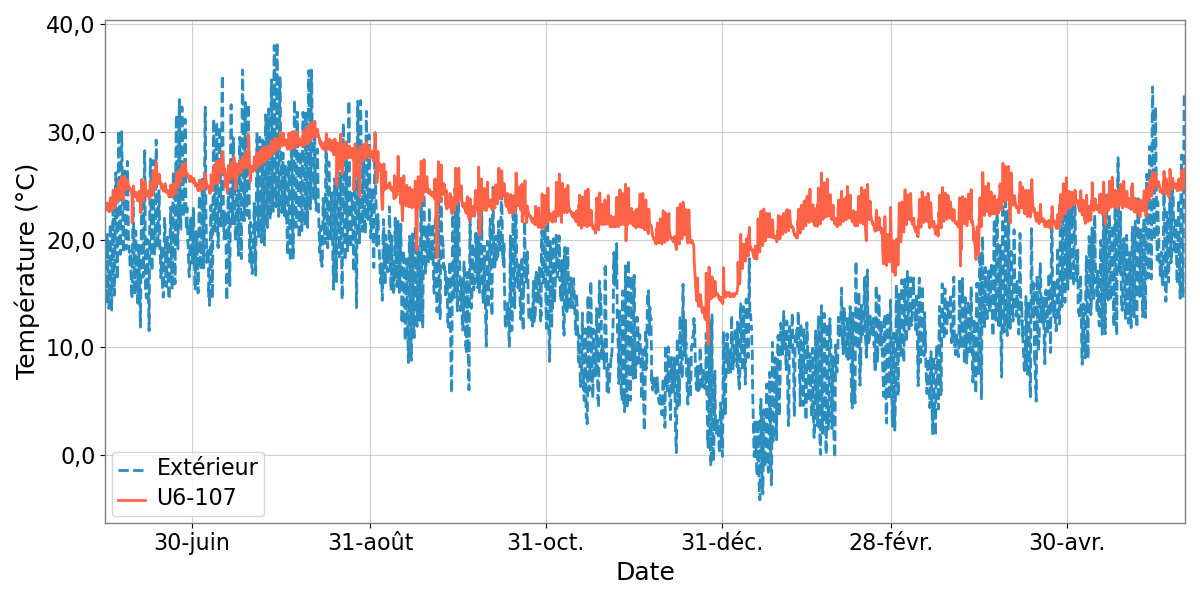

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

for col, color, label, ls, marker, lw, alpha, unc in zip(
    columns_to_plot,
    colors,
    labels,
    linestyles,
    markers,
    widths,
    alphas,
    fixed_uncertainties,
):
    if col in df_period.columns:
        ax.plot(
            df_period.index,
            df_period[col],
            label=label,
            color=color,
            linestyle=ls,
            marker=marker,
            linewidth=lw,
            alpha=alpha,
        )
    # Add constant uncertainty shading
    ax.fill_between(
        df_period.index,
        df_period[col] - unc,
        df_period[col] + unc,
        color=color,
        alpha=0.1,
    )

# Forcer les limites de l'axe x pour supprimer les marges
ax.set_xlim([df_period.index.min(), df_period.index.max() + pd.Timedelta(hours=0.2)])

ax.set_xlabel("Date")
ax.set_ylabel("Température (°C)")
ax.legend(frameon=False)
ax.grid(True, linestyle="-", alpha=0.5)

locale.setlocale(locale.LC_TIME, "French_France.1252")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))  # %H:%M' ))
# ax.xaxis.set_major_locator(mdates.HourLocator(interval=24))
# plt.gcf().autofmt_xdate()

# Decimal comma formatter for y-axis ---
def comma_format(x, pos):
    return f"{x:.1f}".replace(".", ",")  # 1 decimal for temperature

ax.yaxis.set_major_formatter(FuncFormatter(comma_format))

# Apply the custom theme
apply_my_theme(ax)
fig.tight_layout()
plt.show()

### Dataset summary

In [10]:
# Describe
df_107.describe()

,outTemp_C,WATECO_1F0B_Temperature_u6_107
count,15002.000000,15002.000000
mean,15.554716,23.687327
std,7.583536,3.435666
min,-7.527778,10.250000
25%,10.129630,21.650000
50%,15.157407,23.400000
75%,20.750000,25.850000
max,40.907407,33.150000


In [11]:
# NaN
df_107.isna().sum()

outTemp_C                         0
WATECO_1F0B_Temperature_u6_107    0
dtype: int64

### Global Distribution
In this section, we explore the **distribution of the temperature values** measured by the sensor.

Instead of looking at temperature over time, we analyze **how often different temperature values occur** in the dataset.

This helps us understand the overall behavior of the measurements.

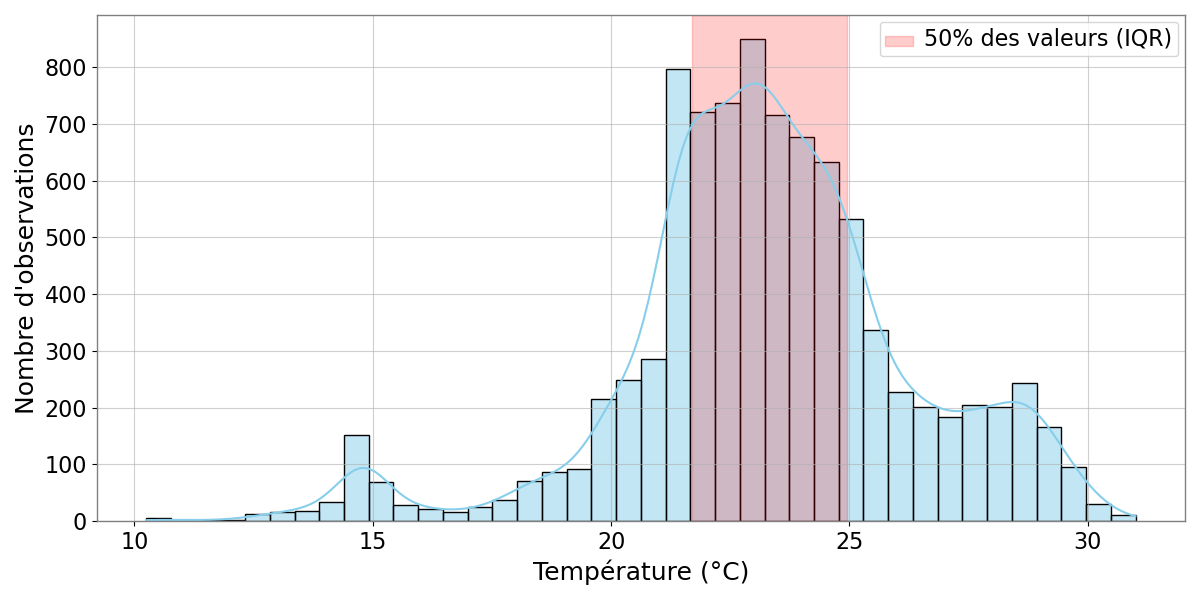

In [12]:
# Distribution
df_T = df_period["WATECO_1F0B_Temperature_u6_107"]

# Compute percentiles
q25 = df_T.quantile(0.25)
q75 = df_T.quantile(0.75)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
sns.histplot(df_T, bins=40, kde=True, color="skyblue", ax=ax)

# Highlight the 50% zone (IQR)
ax.axvspan(q25, q75, color="red", alpha=0.2, label="50% des valeurs (IQR)")

# Titles and labels
ax.set_title("Distribution of temperature value with KDE")
ax.set_xlabel("Température (°C)")
ax.set_ylabel("Nombre d'observations")

ax.grid(True, alpha=0.5)
ax.legend()

# Decimal comma formatter for y-axis
from matplotlib.ticker import FuncFormatter

def comma_format(x, pos):
    return f"{x:.0f}".replace(".", ",")

ax.yaxis.set_major_formatter(FuncFormatter(comma_format))

# Apply the custom theme
apply_my_theme(ax)

fig.tight_layout()
plt.show()

### Boxplot / violinplot
In this section, we analyze how the **temperature distribution changes across the months of the year**.

Instead of plotting temperature continuously over time, we group the data by **month** and examine how the values are distributed within each month.

This visualization allows us to:

- compare **temperature variability between months**
- observe **seasonal patterns**
- detect **months with larger variability**
- identify **possible outliers or extreme values**

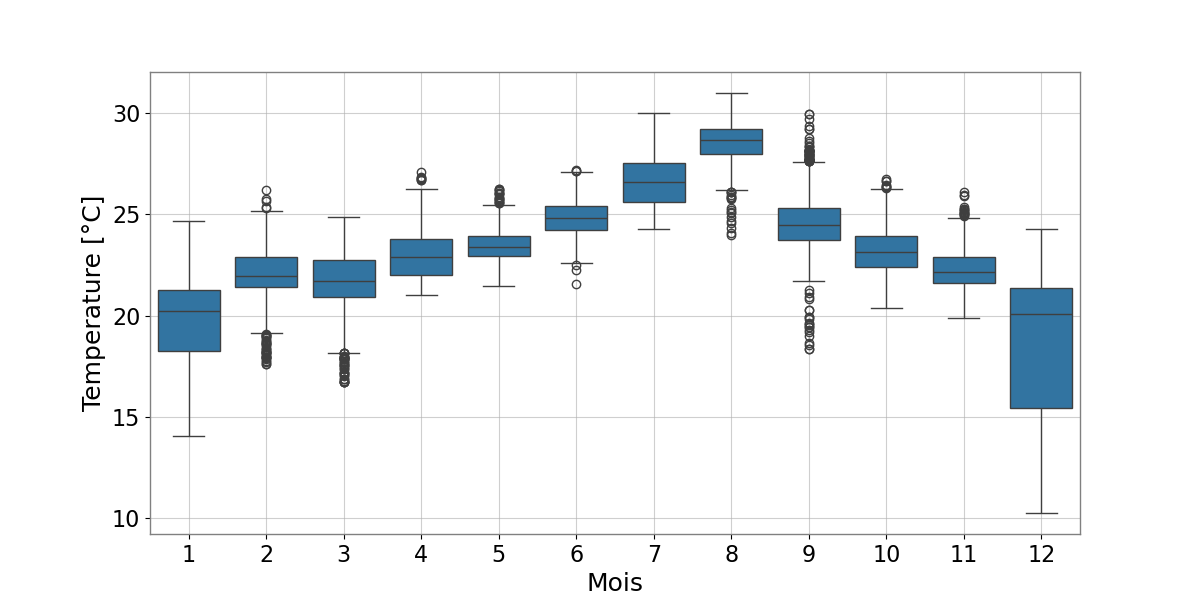

In [13]:
# Violin plot / boxplot
# sns.violinplot() – Shows density + quartiles
# sns.stripplot() – Scatter of individual data points
# sns.boxenplot() – Better for large datasets (letter-value plot)
# sns.histplot() – Histogram

df = df_period.copy()
df["month"] = df.index.month

fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df, x="month", y="WATECO_1F0B_Temperature_u6_107", ax=ax, color="#1f77b4"
)

ax.set_xlabel("Mois")
ax.set_ylabel("Temperature [°C]")

apply_my_theme(ax)
plt.show()

### Monthly Temperature Distribution with KDE

In this section, we **visualize the distribution of temperatures for each month** using a **Kernel Density Estimate (KDE)**.

Instead of showing individual points or daily averages, we look at **how temperatures are distributed within each month**, with curves normalized for visual comparison.

This helps us **identify seasonal patterns** and see which months tend to be warmer or cooler in a clear, comparative way.

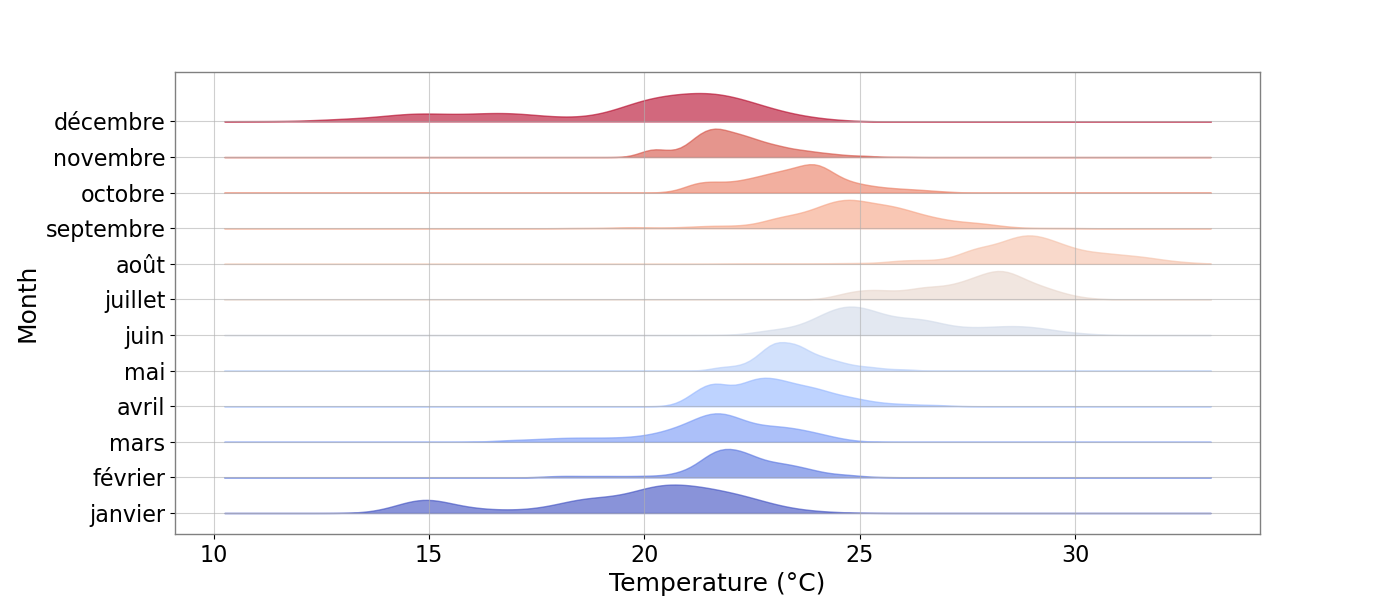

In [14]:
import calendar

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

temp = df_107.copy()
temp = temp.reset_index()

temp["month_num"] = temp["timestamp"].dt.month
months = sorted(temp["month_num"].unique())

fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(months)))

for i, month in enumerate(months):
    data = temp[temp["month_num"] == month]["WATECO_1F0B_Temperature_u6_107"].dropna()
    if len(data) > 1:
        kde = gaussian_kde(data)
        x_vals = np.linspace(
            temp["WATECO_1F0B_Temperature_u6_107"].min(),
            temp["WATECO_1F0B_Temperature_u6_107"].max(),
            200,
        )
        y_vals = kde(x_vals)

        # Normalize KDE so curves are visually comparable
        y_vals = y_vals / y_vals.max() * 0.8
        y_offset = y_vals + month

        ax.fill_between(
            x_vals,
            month,
            y_offset,
            color=colors[i],
            alpha=0.6,
        )

ax.set_yticks(months)
ax.set_yticklabels([calendar.month_name[m] for m in months])
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Month")
ax.set_title("KDE of Temperature per Month (Normalized for Visibility)")

apply_my_theme(ax)

plt.show()

### Heatmaps throught the year
In this section, we visualize the daily average temperatures for 2025 using a calendar-style heatmap.

Instead of looking at the temperature as a continuous time series, we organize the data by **weekday and week of the month** to see patterns across months and weeks.

In [15]:
# Définir la période à tracer
start_date = "2025-01-01"
end_date = "2025-12-27"

# Filtrer le DataFrame sur l'index (qui doit être de type datetime)
df_107_heatmaps = df_107.loc[start_date:end_date]

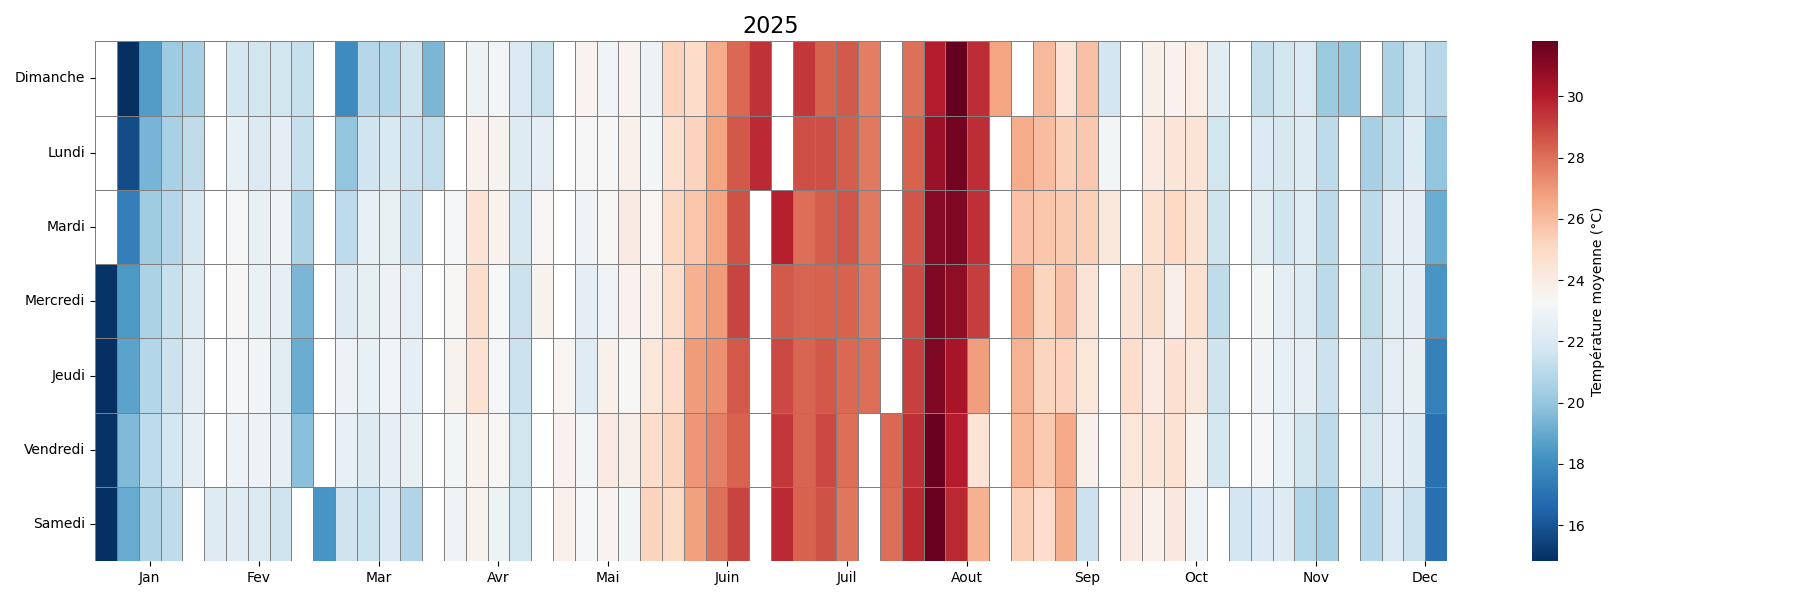

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Daily mean
daily_mean = df_107_heatmaps["WATECO_1F0B_Temperature_u6_107"].resample("D").mean()
calendar_df = daily_mean.to_frame(name="mean_temp")

# Extraire infos date
calendar_df["year"] = calendar_df.index.year
calendar_df["month"] = calendar_df.index.month
calendar_df["weekday"] = calendar_df.index.weekday  # lundi=0
calendar_df["day"] = calendar_df.index.day

# Faire commencer dimanche=0
calendar_df["weekday"] = (calendar_df["weekday"] + 1) % 7


# Fonction pour générer une "position de semaine dans le mois"
def week_of_month(dt):
    first_day = dt.replace(day=1)
    return (dt.day + first_day.weekday()) // 7

calendar_df["week_of_month"] = calendar_df.index.to_series().apply(week_of_month)

# Pivot pour heatmap
heatmap_matrix = calendar_df.pivot_table(
    index="weekday", columns=["month", "week_of_month"], values="mean_temp"
)

# Plot
fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    heatmap_matrix,
    cmap="RdBu_r",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Température moyenne (°C)"},
    ax=ax,
)

# Jours de la semaine
day_labels = ["Dimanche", "Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi"]
ax.set_yticks(np.arange(7) + 0.5)
ax.set_yticklabels(day_labels, rotation=0)

ax.set_xlabel("")
ax.set_ylabel("")

# Ajouter labels des mois au-dessus
month_positions = []
month_names = [
    "Jan",
    "Fev",
    "Mar",
    "Avr",
    "Mai",
    "Juin",
    "Juil",
    "Aout",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

col_idx = 0
month_ticks = []
month_labels = []
for month in sorted(calendar_df["month"].unique()):
    weeks_in_month = (
        calendar_df[calendar_df["month"] == month]["week_of_month"].max() + 1
    )
    month_center = col_idx + weeks_in_month / 2
    month_ticks.append(month_center)
    month_labels.append(month_names[month - 1])
    col_idx += weeks_in_month

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, rotation=0)

plt.title("2025", fontsize=16)
plt.tight_layout()
plt.show()

### Heatmap of Temperature by Day and Hour

In this section, we visualize the temperature measurements across **days and hours** using a heatmap.

Instead of summarizing temperature by day or week, we look at **hourly variations for each day**, which allows us to see daily patterns and anomalies in the measurements.

This helps us understand **how temperature changes throughout the day** and how these daily patterns evolve over time.

In [18]:
# Copie propre
df_heatmap = df_107.copy()

# S'assurer que l'index est en datetime
df_heatmap.index = pd.to_datetime(df_heatmap.index)

# Extraire jour et heure
df_heatmap["date"] = df_heatmap.index.date
df_heatmap["hour"] = df_heatmap.index.hour

# Créer la matrice pour la heatmap
heatmap_data = df_heatmap.pivot_table(
    values="WATECO_1F0B_Temperature_u6_107",  # "outTemp_C", #
    index="hour",
    columns="date",
    aggfunc="mean",  # moyenne si plusieurs valeurs par heure
)
# heatmap_data = heatmap_data.sort_index(ascending=True)

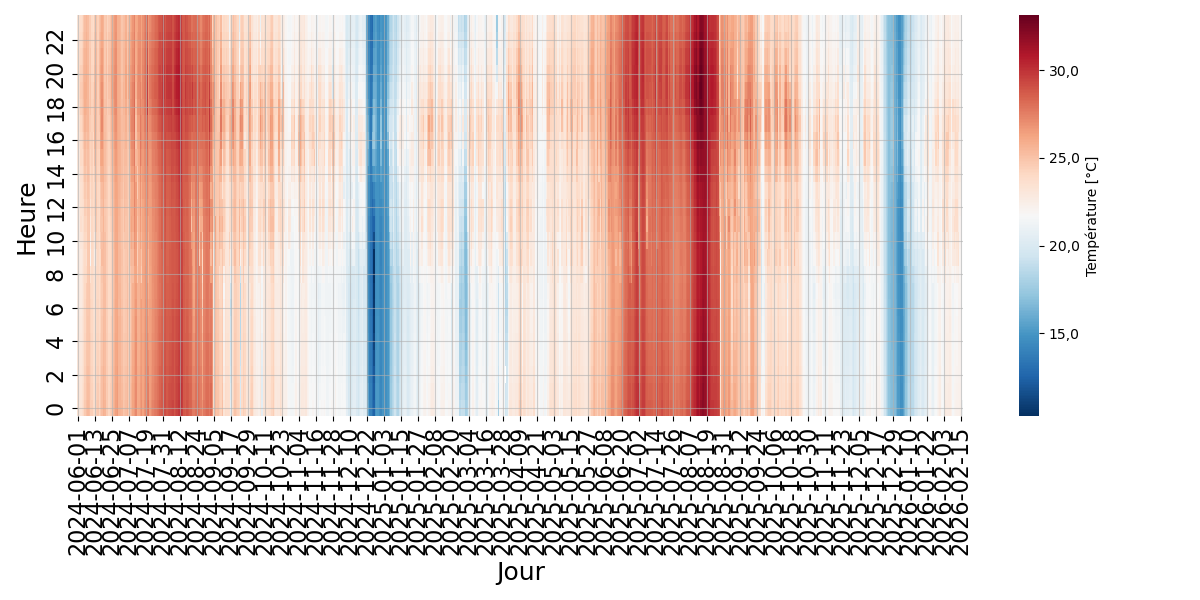

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    heatmap_data, cmap="RdBu_r", ax=ax, cbar_kws={"label": "Température [°C]"}
)

ax.set_xlabel("Jour")
ax.set_ylabel("Heure")
ax.set_title("Heatmap des températures (Jour × Heure)")

# Inverser l'axe Y pour avoir 0h en bas
ax.invert_yaxis()

# ---- Format heure propre ----
ax.set_yticks(np.arange(0.5, 24.5, 2))
ax.set_yticklabels(range(0, 24, 2))

# ---- Format décimal virgule pour la colorbar ----
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
)

apply_my_theme(ax)

fig.tight_layout()
plt.show()